In [1]:
list.files("/content")

[1] "complaints.csv" "customers.csv"  "deliveries.csv" "orders.csv"    
[5] "sample_data"

In [2]:
install.packages("sqldf")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’




In [3]:
library(sqldf)

customers <- read.csv("/content/customers.csv")
orders <- read.csv("/content/orders.csv")
deliveries <- read.csv("/content/deliveries.csv")
complaints <- read.csv("/content/complaints.csv")

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



In [4]:
sqldf("
SELECT service_type, COUNT(*) as total_orders
FROM orders
GROUP BY service_type
")

service_type,total_orders
<chr>,<int>
Business,165
Medical,139
Parcel,308
Passenger,341
Retail,297


In [5]:
sqldf("
SELECT delivery_status,
AVG(customer_rating_post_delivery) as avg_rating
FROM deliveries
GROUP BY delivery_status
")

delivery_status,avg_rating
<chr>,<dbl>
Delayed,3.114975
Failed,3.049313
OnTime,4.283273


In [7]:
sqldf("
SELECT complaint_type,
COUNT(*) as total_complaints
FROM complaints
GROUP BY complaint_type
ORDER BY total_complaints DESC
")

complaint_type,total_complaints
<chr>,<int>
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


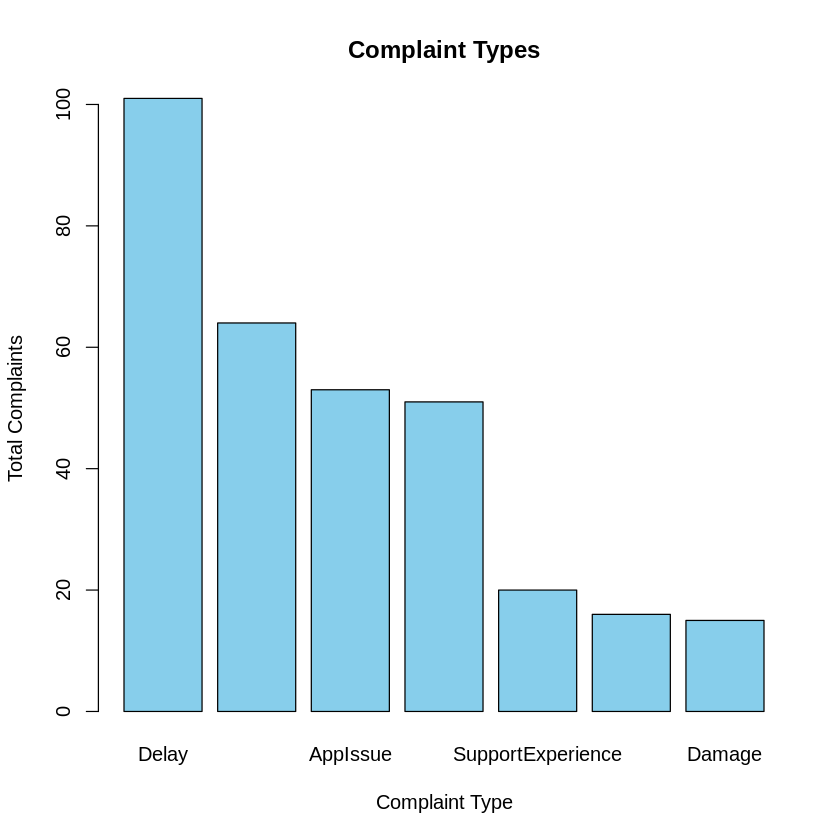

In [8]:
complaint_data <- sqldf("
SELECT complaint_type,
COUNT(*) as total_complaints
FROM complaints
GROUP BY complaint_type
ORDER BY total_complaints DESC
")

barplot(
  complaint_data$total_complaints,
  names.arg = complaint_data$complaint_type,
  col = "skyblue",
  main = "Complaint Types",
  xlab = "Complaint Type",
  ylab = "Total Complaints"
)